# EDA: Domiciliation by country of birth and sex

**Data source:** DuckDB view `domiciliation` (loaded from `data/processed/domiciliation.parquet`)  
**Run `notebooks/load/02_load_domiciliation.ipynb` first.**

**Charts produced:**
- `domicil_aruba_neth_ant_by_sex.png` — Aruba/Neth. Ant. domiciliations by sex, 2015–2023
- `domicil_trends_by_country_sex.png` — subplot grid: all countries, domiciliations by sex

---
## 1. Setup

In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent if Path.cwd().name == "eda" else Path.cwd()))

from config.project_paths import DB_FILES, FIGURES

In [7]:
con = duckdb.connect(str(DB_FILES / "aruba.duckdb"))

# Quick check
print(con.execute("SELECT COUNT(*) FROM domiciliation").fetchone())
print(con.execute("SELECT DISTINCT country FROM domiciliation ORDER BY country").df())

(108,)
              country
0   Aruba/ Neth. Ant.
1            Colombia
2  Dominican Republic
3               Other
4     The Netherlands
5           Venezuela


---
## 2. Load data from DuckDB

Exclude the total row for country-level charts.

In [8]:
df = con.execute("""
    SELECT country, year, sex, value
    FROM domiciliation
    WHERE country != 'Total Domiciliation:'
    ORDER BY country, year, sex
""").df()

con.close()

print(f"Shape: {df.shape}")
df.head()

Shape: (108, 4)


,country,year,sex,value
0,Aruba/ Neth. Ant.,2015,Female,420
1,Aruba/ Neth. Ant.,2015,Male,432
2,Aruba/ Neth. Ant.,2016,Female,389
3,Aruba/ Neth. Ant.,2016,Male,415
4,Aruba/ Neth. Ant.,2017,Female,416


---
## 3. Chart 1: Aruba / Neth. Ant. domiciliations by sex

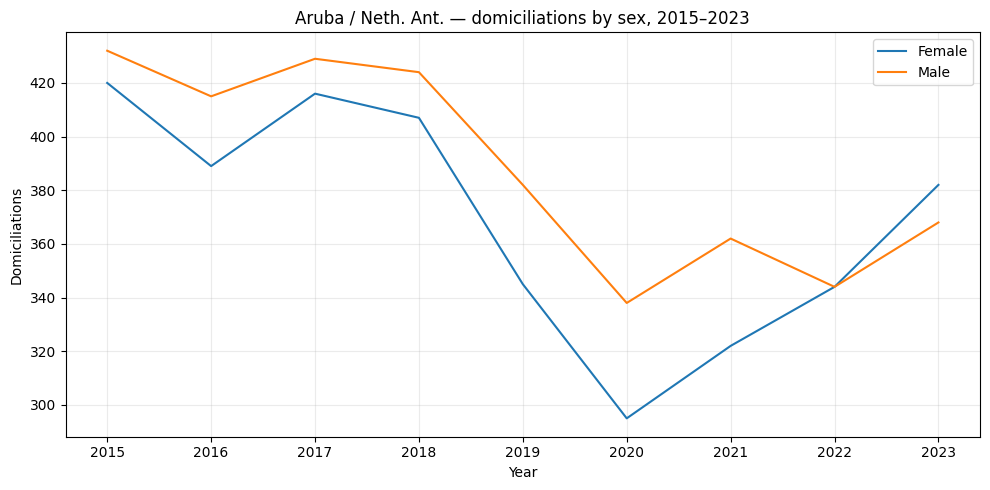

Saved: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/outputs/figures/domicil_aruba_neth_ant_by_sex.png


In [9]:
df_aruba = df[df["country"] == "Aruba/ Neth. Ant."].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid(alpha=0.25)

for sex, group in df_aruba.groupby("sex"):
    ax.plot(group["year"], group["value"], label=sex)

ax.set_title("Aruba / Neth. Ant. — domiciliations by sex, 2015–2023")
ax.set_xlabel("Year")
ax.set_ylabel("Domiciliations")
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES / "domicil_aruba_neth_ant_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", FIGURES / "domicil_aruba_neth_ant_by_sex.png")

---
## 4. Chart 2: All countries — subplot grid by sex

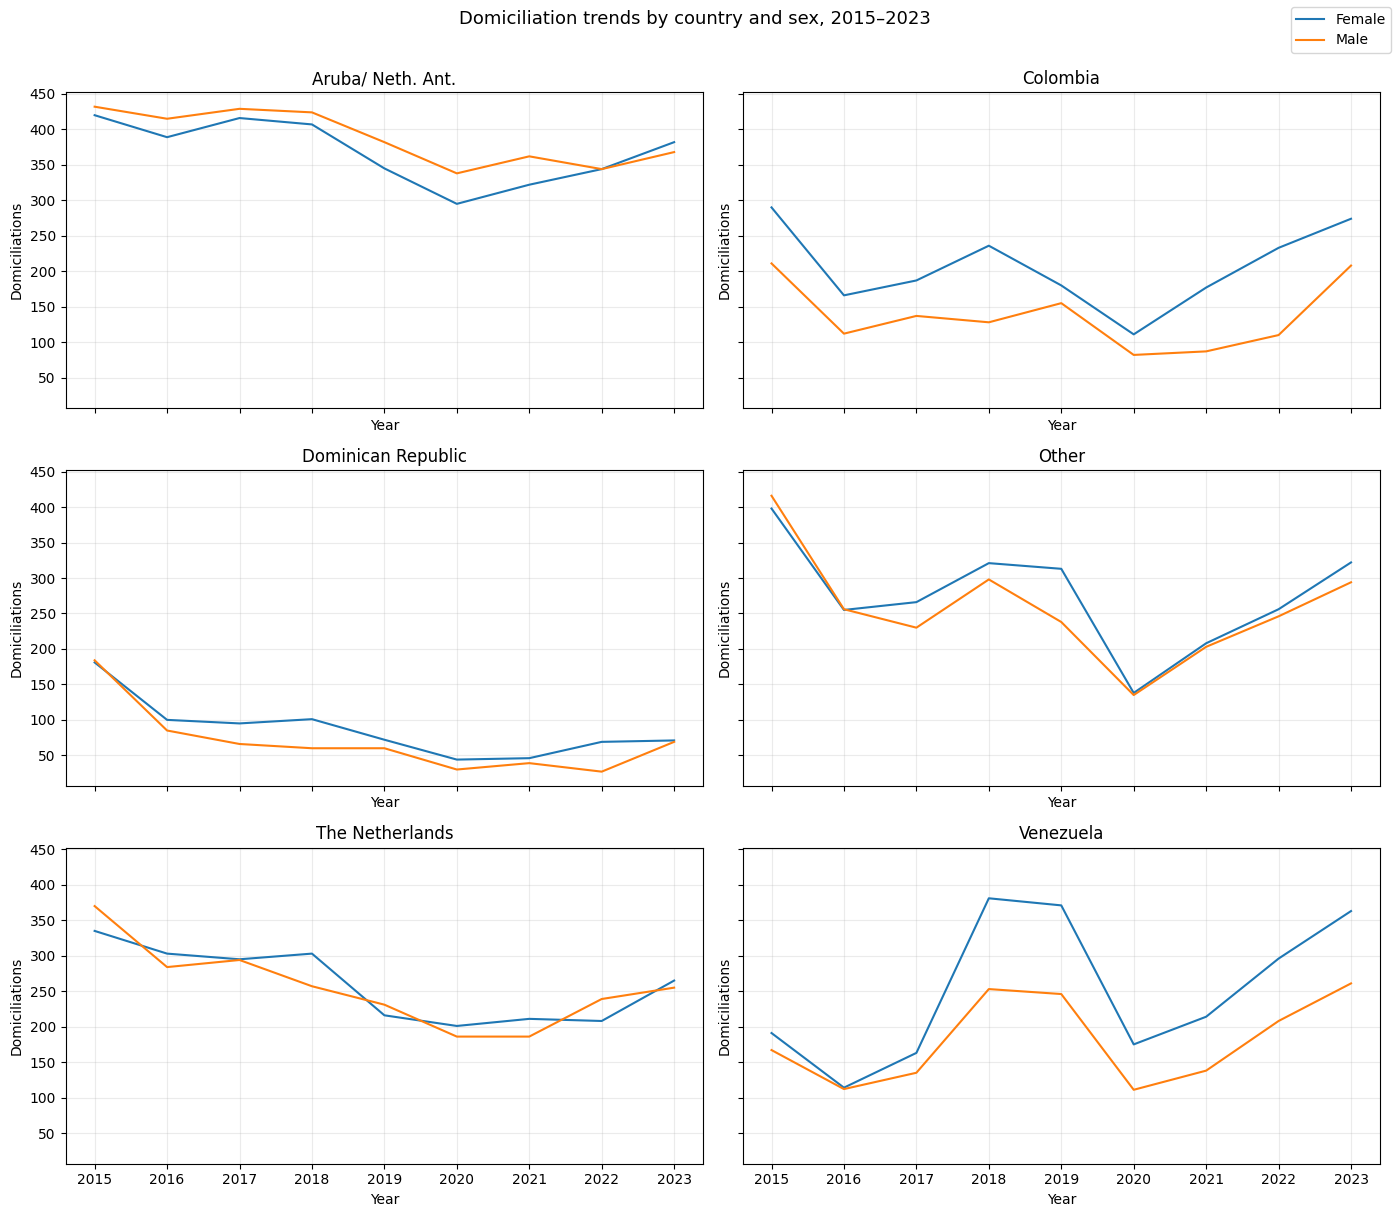

Saved: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/outputs/figures/domicil_trends_by_country_sex.png


In [10]:
countries = sorted(df["country"].unique())

ncols = 2
nrows = (len(countries) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(14, 4 * nrows),
    sharex=True, sharey=True
)
axes = axes.flatten()

for ax, country in zip(axes, countries):
    country_data = df[df["country"] == country]
    for sex, group in country_data.groupby("sex"):
        ax.plot(group["year"], group["value"], label=sex)
    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("Domiciliations")
    ax.grid(True, alpha=0.25)

# Remove unused axes
for ax in axes[len(countries):]:
    fig.delaxes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=1)
fig.suptitle("Domiciliation trends by country and sex, 2015–2023", y=1.01, fontsize=13)
fig.tight_layout()

fig.savefig(FIGURES / "domicil_trends_by_country_sex.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", FIGURES / "domicil_trends_by_country_sex.png")